# Step-by-Step Tutorial: Ensemble Learning with Boosting in scikit-learn

This notebook introduces **boosting**, a family of ensemble learning methods where models are trained sequentially.

The notebook uses only boosting methods supported by `scikit-learn`:

1. `AdaBoostClassifier`
2. `AdaBoostRegressor`
3. `GradientBoostingClassifier`
4. `GradientBoostingRegressor`
5. `HistGradientBoostingClassifier`
6. `HistGradientBoostingRegressor`

## Learning objectives

By the end of this tutorial, students should be able to:

1. Explain the basic idea of boosting.
2. Explain how boosting differs from bagging.
3. Train AdaBoost models for classification and regression.
4. Train Gradient Boosting models for classification and regression.
5. Train Histogram-based Gradient Boosting models.
6. Explain important hyperparameters such as `n_estimators`, `learning_rate`, `max_depth`, and `max_iter`.
7. Visualize how boosting models improve over iterations.
8. Compare boosting models with simple baseline models.
9. Understand overfitting risks in boosting.
10. Use cross-validation to tune boosting hyperparameters.

## Required libraries

This notebook uses:

- `numpy`
- `pandas`
- `matplotlib`
- `scikit-learn`

## 1. What is boosting?

Boosting is an ensemble learning method.

The main idea is:

> Train many weak models sequentially, where each new model tries to correct the mistakes of the previous models.

A **weak learner** is a model that performs only slightly better than random guessing.

In many boosting methods, weak learners are shallow decision trees.

For example, AdaBoost often uses a decision tree with depth 1, also called a **decision stump**.

## Boosting intuition

Imagine we train a model and it misclassifies some examples.

Boosting asks:

> Which examples were difficult?

Then the next model focuses more strongly on those difficult examples.

After many rounds, the final model combines all weak models.

## Bagging vs Boosting

| Aspect | Bagging | Boosting |
|---|---|---|
| Training | Models are trained mostly independently | Models are trained sequentially |
| Main goal | Reduce variance | Reduce bias and improve difficult cases |
| Typical base learner | Deep decision trees | Shallow decision trees |
| Example | Bagging, Random Forest | AdaBoost, Gradient Boosting |
| Risk | May not improve biased models much | Can overfit if too many stages or too high learning rate |

## 2. Boosting methods in this notebook

`scikit-learn` supports several boosting estimators.

| Method | Classification | Regression | Main idea |
|---|---|---|---|
| AdaBoost | `AdaBoostClassifier` | `AdaBoostRegressor` | Reweight difficult examples |
| Gradient Boosting | `GradientBoostingClassifier` | `GradientBoostingRegressor` | Fit new trees to loss gradients/residuals |
| Histogram Gradient Boosting | `HistGradientBoostingClassifier` | `HistGradientBoostingRegressor` | Faster gradient boosting using feature histograms |

## Important note

Histogram-based Gradient Boosting is usually faster for larger tabular datasets and has native support for missing values.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_moons, make_regression
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.linear_model import LogisticRegression, LinearRegression

from sklearn.ensemble import (
    AdaBoostClassifier,
    AdaBoostRegressor,
    GradientBoostingClassifier,
    GradientBoostingRegressor,
    HistGradientBoostingClassifier,
    HistGradientBoostingRegressor
)

RANDOM_STATE = 42

## 3. Helper functions

We define helper functions for:

1. plotting decision boundaries,
2. evaluating classifiers,
3. evaluating regressors.

In [2]:
def plot_decision_boundary(model, X, y, title):
    # Plot a 2D decision boundary for a fitted classifier.
    x_min, x_max = X[:, 0].min() - 0.7, X[:, 0].max() + 0.7
    y_min, y_max = X[:, 1].min() - 0.7, X[:, 1].max() + 0.7

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 300),
        np.linspace(y_min, y_max, 300)
    )

    grid = np.c_[xx.ravel(), yy.ravel()]
    predictions = model.predict(grid).reshape(xx.shape)

    plt.figure(figsize=(7, 5))
    plt.contourf(xx, yy, predictions, alpha=0.25)
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolor="black", alpha=0.8)
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.title(title)
    plt.grid(True)
    plt.show()


def evaluate_classifier(model, X_train, X_test, y_train, y_test, model_name):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    return {
        "model": model_name,
        "train_accuracy": model.score(X_train, y_train),
        "test_accuracy": accuracy_score(y_test, y_pred)
    }


def evaluate_regressor(model, X_train, X_test, y_train, y_test, model_name):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    return {
        "model": model_name,
        "train_r2": model.score(X_train, y_train),
        "test_r2": r2_score(y_test, y_pred),
        "test_mae": mean_absolute_error(y_test, y_pred),
        "test_rmse": np.sqrt(mean_squared_error(y_test, y_pred))
    }

# Part A: Boosting for Classification

## 4. Create a classification dataset

We use a two-dimensional moon-shaped dataset.

This dataset is nonlinear, so it is useful for visualizing decision boundaries.

In [3]:
X_clf, y_clf = make_moons(
    n_samples=600,
    noise=0.30,
    random_state=RANDOM_STATE
)

X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X_clf,
    y_clf,
    test_size=0.30,
    random_state=RANDOM_STATE,
    stratify=y_clf
)

print("Training shape:", X_train_clf.shape)
print("Test shape:", X_test_clf.shape)

Training shape: (420, 2)
Test shape: (180, 2)


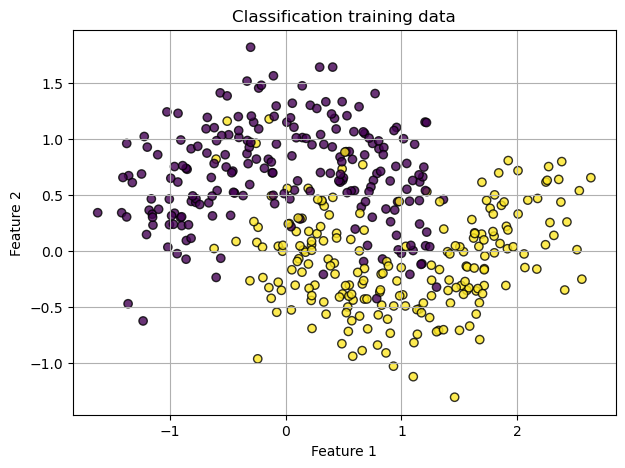

In [4]:
plt.figure(figsize=(7, 5))
plt.scatter(X_train_clf[:, 0], X_train_clf[:, 1], c=y_train_clf, edgecolor="black", alpha=0.8)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Classification training data")
plt.grid(True)
plt.show()

## 5. Baseline classifiers

Before using boosting, we train two simple baseline models:

1. Logistic Regression
2. A shallow Decision Tree

This gives us a comparison point.

In [5]:
baseline_logistic = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(random_state=RANDOM_STATE))
])

baseline_tree = DecisionTreeClassifier(
    max_depth=2,
    random_state=RANDOM_STATE
)

baseline_clf_results = []

for name, model in [
    ("Logistic Regression", baseline_logistic),
    ("Shallow Decision Tree", baseline_tree)
]:
    baseline_clf_results.append(
        evaluate_classifier(
            model,
            X_train_clf,
            X_test_clf,
            y_train_clf,
            y_test_clf,
            name
        )
    )

pd.DataFrame(baseline_clf_results)

,model,train_accuracy,test_accuracy
0,Logistic Regression,0.861905,0.833333
1,Shallow Decision Tree,0.895238,0.872222


## 6. AdaBoostClassifier

AdaBoost trains weak learners sequentially.

The next learner focuses more on examples that were misclassified by previous learners.

In `scikit-learn`, we use:

```python
AdaBoostClassifier
```

Important parameters:

| Parameter | Meaning |
|---|---|
| `estimator` | The weak learner |
| `n_estimators` | Number of boosting rounds |
| `learning_rate` | Shrinks the contribution of each learner |
| `random_state` | Makes results reproducible |

The default weak learner is a decision stump.

In [6]:
adaboost_clf = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=1, random_state=RANDOM_STATE),
    n_estimators=100,
    learning_rate=0.5,
    random_state=RANDOM_STATE
)

adaboost_clf_result = evaluate_classifier(
    adaboost_clf,
    X_train_clf,
    X_test_clf,
    y_train_clf,
    y_test_clf,
    "AdaBoost Classifier"
)

pd.DataFrame(baseline_clf_results + [adaboost_clf_result])

,model,train_accuracy,test_accuracy
0,Logistic Regression,0.861905,0.833333
1,Shallow Decision Tree,0.895238,0.872222
2,AdaBoost Classifier,0.911905,0.894444


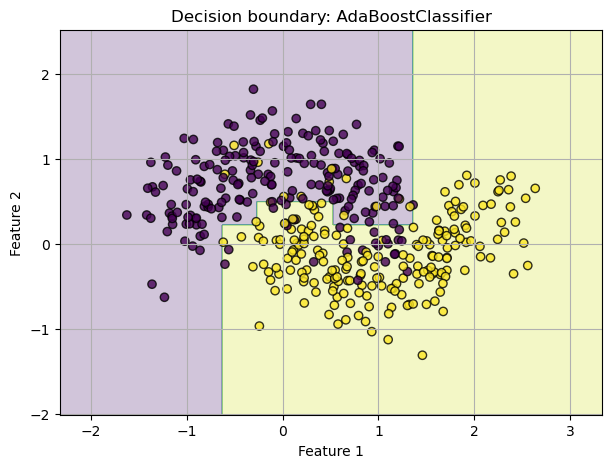

In [7]:
adaboost_clf.fit(X_train_clf, y_train_clf)

plot_decision_boundary(
    adaboost_clf,
    X_train_clf,
    y_train_clf,
    "Decision boundary: AdaBoostClassifier"
)

## 7. GradientBoostingClassifier

Gradient Boosting also trains models sequentially.

Instead of only reweighting difficult examples, it fits new trees to the direction that reduces the loss.

For classification, the default loss is log loss.

Important parameters:

| Parameter | Meaning |
|---|---|
| `n_estimators` | Number of boosting stages |
| `learning_rate` | Shrinks each tree's contribution |
| `max_depth` | Depth of individual regression trees |
| `subsample` | Fraction of samples used per boosting stage |
| `random_state` | Makes results reproducible |

A lower `learning_rate` often requires a larger `n_estimators`.

In [8]:
gb_clf = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=2,
    random_state=RANDOM_STATE
)

gb_clf_result = evaluate_classifier(
    gb_clf,
    X_train_clf,
    X_test_clf,
    y_train_clf,
    y_test_clf,
    "Gradient Boosting Classifier"
)

pd.DataFrame(baseline_clf_results + [
    adaboost_clf_result,
    gb_clf_result
])

,model,train_accuracy,test_accuracy
0,Logistic Regression,0.861905,0.833333
1,Shallow Decision Tree,0.895238,0.872222
2,AdaBoost Classifier,0.911905,0.894444
3,Gradient Boosting Classifier,0.954762,0.888889


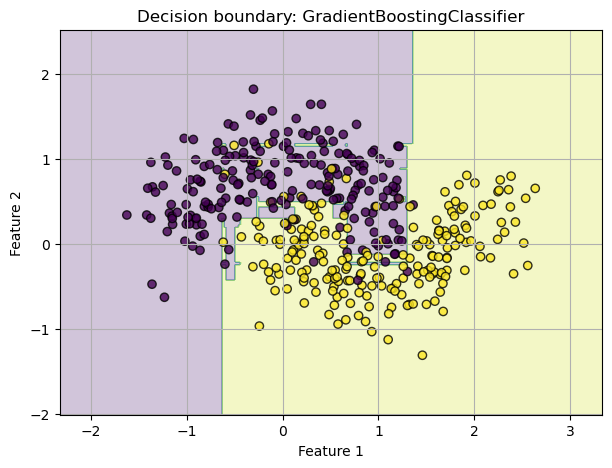

In [9]:
gb_clf.fit(X_train_clf, y_train_clf)

plot_decision_boundary(
    gb_clf,
    X_train_clf,
    y_train_clf,
    "Decision boundary: GradientBoostingClassifier"
)

## 8. HistGradientBoostingClassifier

Histogram-based Gradient Boosting is a faster variant of gradient boosting.

It bins continuous features into histograms, which can speed up training.

It is especially useful for larger tabular datasets.

Important parameters:

| Parameter | Meaning |
|---|---|
| `max_iter` | Number of boosting iterations |
| `learning_rate` | Shrinks each iteration's contribution |
| `max_leaf_nodes` | Maximum number of leaves per tree |
| `max_depth` | Maximum tree depth |
| `early_stopping` | Stops training if validation performance stops improving |

In [10]:
hist_gb_clf = HistGradientBoostingClassifier(
    max_iter=100,
    learning_rate=0.1,
    max_leaf_nodes=15,
    random_state=RANDOM_STATE
)

hist_gb_clf_result = evaluate_classifier(
    hist_gb_clf,
    X_train_clf,
    X_test_clf,
    y_train_clf,
    y_test_clf,
    "HistGradientBoosting Classifier"
)

pd.DataFrame(baseline_clf_results + [
    adaboost_clf_result,
    gb_clf_result,
    hist_gb_clf_result
])

,model,train_accuracy,test_accuracy
0,Logistic Regression,0.861905,0.833333
1,Shallow Decision Tree,0.895238,0.872222
2,AdaBoost Classifier,0.911905,0.894444
3,Gradient Boosting Classifier,0.954762,0.888889
4,HistGradientBoosting Classifier,1.000000,0.883333


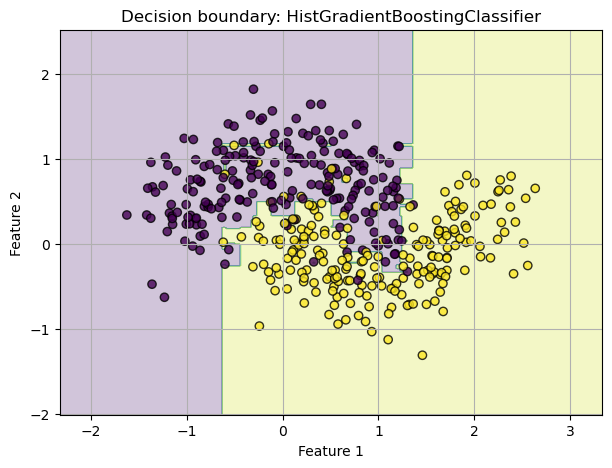

In [11]:
hist_gb_clf.fit(X_train_clf, y_train_clf)

plot_decision_boundary(
    hist_gb_clf,
    X_train_clf,
    y_train_clf,
    "Decision boundary: HistGradientBoostingClassifier"
)

## 9. Classification comparison

In [12]:
classification_results = pd.DataFrame(baseline_clf_results + [
    adaboost_clf_result,
    gb_clf_result,
    hist_gb_clf_result
]).sort_values("test_accuracy", ascending=False)

classification_results

,model,train_accuracy,test_accuracy
2,AdaBoost Classifier,0.911905,0.894444
3,Gradient Boosting Classifier,0.954762,0.888889
4,HistGradientBoosting Classifier,1.000000,0.883333
1,Shallow Decision Tree,0.895238,0.872222
0,Logistic Regression,0.861905,0.833333


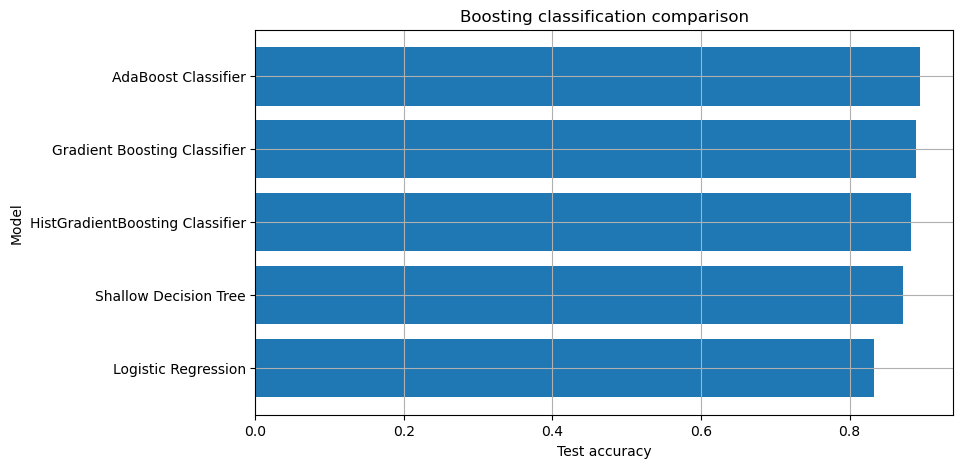

In [13]:
plt.figure(figsize=(9, 5))
plt.barh(classification_results["model"], classification_results["test_accuracy"])
plt.xlabel("Test accuracy")
plt.ylabel("Model")
plt.title("Boosting classification comparison")
plt.gca().invert_yaxis()
plt.grid(True)
plt.show()

## 10. Boosting over iterations

Boosting builds the model stage by stage.

`AdaBoostClassifier` and `GradientBoostingClassifier` provide staged predictions.

This allows us to observe how performance changes as more boosting stages are added.

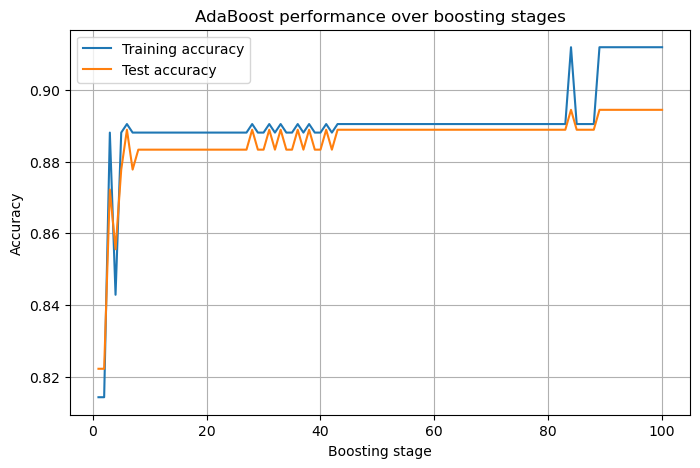

In [14]:
adaboost_clf.fit(X_train_clf, y_train_clf)

ada_train_scores = []
ada_test_scores = []

for y_train_stage, y_test_stage in zip(
    adaboost_clf.staged_predict(X_train_clf),
    adaboost_clf.staged_predict(X_test_clf)
):
    ada_train_scores.append(accuracy_score(y_train_clf, y_train_stage))
    ada_test_scores.append(accuracy_score(y_test_clf, y_test_stage))

plt.figure(figsize=(8, 5))
plt.plot(range(1, len(ada_train_scores) + 1), ada_train_scores, label="Training accuracy")
plt.plot(range(1, len(ada_test_scores) + 1), ada_test_scores, label="Test accuracy")
plt.xlabel("Boosting stage")
plt.ylabel("Accuracy")
plt.title("AdaBoost performance over boosting stages")
plt.legend()
plt.grid(True)
plt.show()

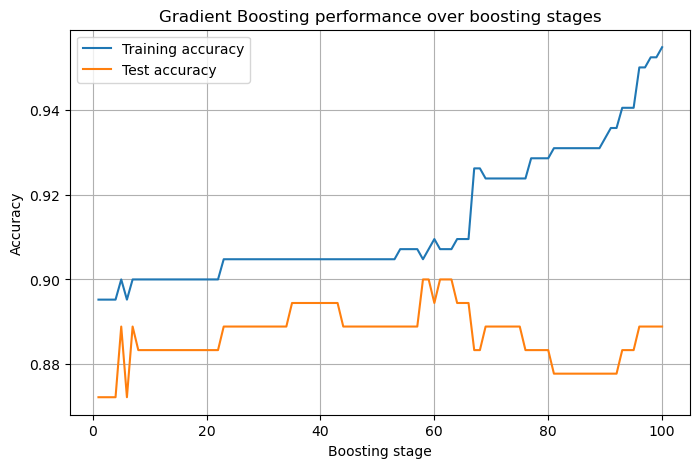

In [15]:
gb_clf.fit(X_train_clf, y_train_clf)

gb_train_scores = []
gb_test_scores = []

for y_train_stage, y_test_stage in zip(
    gb_clf.staged_predict(X_train_clf),
    gb_clf.staged_predict(X_test_clf)
):
    gb_train_scores.append(accuracy_score(y_train_clf, y_train_stage))
    gb_test_scores.append(accuracy_score(y_test_clf, y_test_stage))

plt.figure(figsize=(8, 5))
plt.plot(range(1, len(gb_train_scores) + 1), gb_train_scores, label="Training accuracy")
plt.plot(range(1, len(gb_test_scores) + 1), gb_test_scores, label="Test accuracy")
plt.xlabel("Boosting stage")
plt.ylabel("Accuracy")
plt.title("Gradient Boosting performance over boosting stages")
plt.legend()
plt.grid(True)
plt.show()

### Interpretation

Training performance often improves as the number of boosting stages increases.

Test performance may improve at first, then flatten or decrease.

If training accuracy keeps increasing but test accuracy decreases, the model may be overfitting.

# Part B: Boosting for Regression

## 11. Create a regression dataset

We create a regression dataset with several informative features and noise.

In [16]:
X_reg, y_reg = make_regression(
    n_samples=800,
    n_features=10,
    n_informative=6,
    noise=35,
    random_state=RANDOM_STATE
)

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg,
    y_reg,
    test_size=0.30,
    random_state=RANDOM_STATE
)

print("Training shape:", X_train_reg.shape)
print("Test shape:", X_test_reg.shape)

Training shape: (560, 10)
Test shape: (240, 10)


## 12. Baseline regressors

We train two baseline models:

1. Linear Regression
2. A shallow Decision Tree Regressor

In [17]:
baseline_linear = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LinearRegression())
])

baseline_tree_reg = DecisionTreeRegressor(
    max_depth=3,
    random_state=RANDOM_STATE
)

baseline_reg_results = []

for name, model in [
    ("Linear Regression", baseline_linear),
    ("Shallow Decision Tree Regressor", baseline_tree_reg)
]:
    baseline_reg_results.append(
        evaluate_regressor(
            model,
            X_train_reg,
            X_test_reg,
            y_train_reg,
            y_test_reg,
            name
        )
    )

pd.DataFrame(baseline_reg_results)

,model,train_r2,test_r2,test_mae,test_rmse
0,Linear Regression,0.945498,0.942261,27.212287,35.276259
1,Shallow Decision Tree Regressor,0.561192,0.360767,94.292690,117.375039


## 13. AdaBoostRegressor

AdaBoost can also be used for regression.

The model sequentially focuses on difficult observations.

Important parameters:

| Parameter | Meaning |
|---|---|
| `estimator` | Base regressor |
| `n_estimators` | Number of boosting rounds |
| `learning_rate` | Contribution of each estimator |
| `loss` | Loss function for updating weights |

In [18]:
adaboost_reg = AdaBoostRegressor(
    estimator=DecisionTreeRegressor(max_depth=3, random_state=RANDOM_STATE),
    n_estimators=100,
    learning_rate=0.1,
    loss="linear",
    random_state=RANDOM_STATE
)

adaboost_reg_result = evaluate_regressor(
    adaboost_reg,
    X_train_reg,
    X_test_reg,
    y_train_reg,
    y_test_reg,
    "AdaBoost Regressor"
)

pd.DataFrame(baseline_reg_results + [adaboost_reg_result])

,model,train_r2,test_r2,test_mae,test_rmse
0,Linear Regression,0.945498,0.942261,27.212287,35.276259
1,Shallow Decision Tree Regressor,0.561192,0.360767,94.292690,117.375039
2,AdaBoost Regressor,0.765324,0.675969,68.123898,83.567896


## 14. GradientBoostingRegressor

Gradient Boosting for regression fits each new tree to the residual-like errors of the current ensemble.

For squared error loss, the model tries to reduce prediction residuals.

Important parameters:

| Parameter | Meaning |
|---|---|
| `loss` | Regression loss function |
| `n_estimators` | Number of boosting stages |
| `learning_rate` | Shrinks each tree's contribution |
| `max_depth` | Depth of individual trees |
| `subsample` | Fraction of samples used per stage |

In [19]:
gb_reg = GradientBoostingRegressor(
    loss="squared_error",
    n_estimators=200,
    learning_rate=0.05,
    max_depth=2,
    random_state=RANDOM_STATE
)

gb_reg_result = evaluate_regressor(
    gb_reg,
    X_train_reg,
    X_test_reg,
    y_train_reg,
    y_test_reg,
    "Gradient Boosting Regressor"
)

pd.DataFrame(baseline_reg_results + [
    adaboost_reg_result,
    gb_reg_result
])

,model,train_r2,test_r2,test_mae,test_rmse
0,Linear Regression,0.945498,0.942261,27.212287,35.276259
1,Shallow Decision Tree Regressor,0.561192,0.360767,94.292690,117.375039
2,AdaBoost Regressor,0.765324,0.675969,68.123898,83.567896
3,Gradient Boosting Regressor,0.951747,0.896002,37.064100,47.343343


## 15. HistGradientBoostingRegressor

Histogram-based Gradient Boosting is also available for regression.

It is usually faster than classic Gradient Boosting on larger tabular datasets.

In [20]:
hist_gb_reg = HistGradientBoostingRegressor(
    loss="squared_error",
    max_iter=200,
    learning_rate=0.05,
    max_leaf_nodes=15,
    random_state=RANDOM_STATE
)

hist_gb_reg_result = evaluate_regressor(
    hist_gb_reg,
    X_train_reg,
    X_test_reg,
    y_train_reg,
    y_test_reg,
    "HistGradientBoosting Regressor"
)

pd.DataFrame(baseline_reg_results + [
    adaboost_reg_result,
    gb_reg_result,
    hist_gb_reg_result
])

,model,train_r2,test_r2,test_mae,test_rmse
0,Linear Regression,0.945498,0.942261,27.212287,35.276259
1,Shallow Decision Tree Regressor,0.561192,0.360767,94.292690,117.375039
2,AdaBoost Regressor,0.765324,0.675969,68.123898,83.567896
3,Gradient Boosting Regressor,0.951747,0.896002,37.064100,47.343343
4,HistGradientBoosting Regressor,0.988330,0.878224,39.449085,51.230382


## 16. Regression comparison

In [21]:
regression_results = pd.DataFrame(baseline_reg_results + [
    adaboost_reg_result,
    gb_reg_result,
    hist_gb_reg_result
]).sort_values("test_r2", ascending=False)

regression_results

,model,train_r2,test_r2,test_mae,test_rmse
0,Linear Regression,0.945498,0.942261,27.212287,35.276259
3,Gradient Boosting Regressor,0.951747,0.896002,37.064100,47.343343
4,HistGradientBoosting Regressor,0.988330,0.878224,39.449085,51.230382
2,AdaBoost Regressor,0.765324,0.675969,68.123898,83.567896
1,Shallow Decision Tree Regressor,0.561192,0.360767,94.292690,117.375039


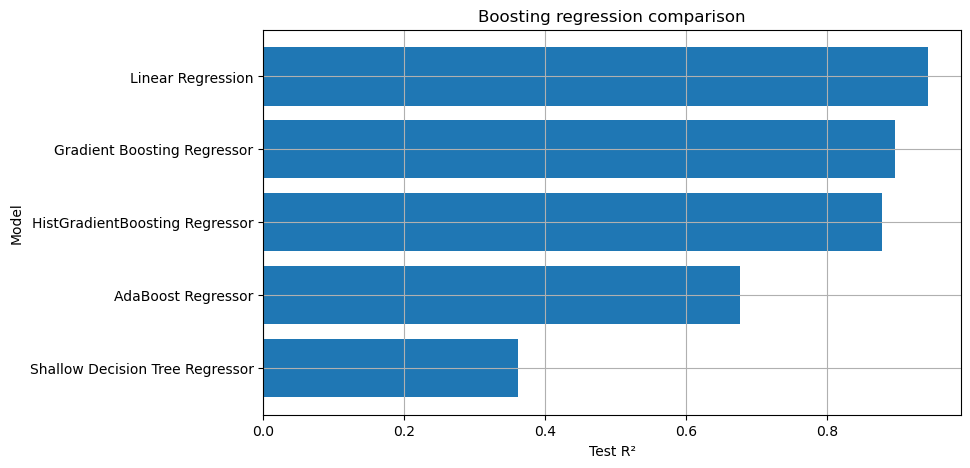

In [22]:
plt.figure(figsize=(9, 5))
plt.barh(regression_results["model"], regression_results["test_r2"])
plt.xlabel("Test R²")
plt.ylabel("Model")
plt.title("Boosting regression comparison")
plt.gca().invert_yaxis()
plt.grid(True)
plt.show()

## 17. True vs predicted values

We visualize predictions from the Histogram Gradient Boosting regressor.

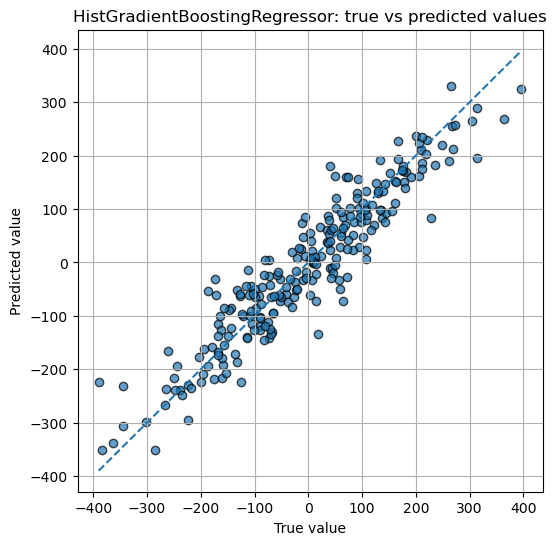

In [23]:
hist_gb_reg.fit(X_train_reg, y_train_reg)
y_pred_hist = hist_gb_reg.predict(X_test_reg)

plt.figure(figsize=(6, 6))
plt.scatter(y_test_reg, y_pred_hist, alpha=0.7, edgecolor="black")
min_value = min(y_test_reg.min(), y_pred_hist.min())
max_value = max(y_test_reg.max(), y_pred_hist.max())
plt.plot([min_value, max_value], [min_value, max_value], linestyle="--")
plt.xlabel("True value")
plt.ylabel("Predicted value")
plt.title("HistGradientBoostingRegressor: true vs predicted values")
plt.grid(True)
plt.show()

## 18. Regression performance over boosting stages

`GradientBoostingRegressor` supports staged predictions.

We can observe how train and test error change over boosting stages.

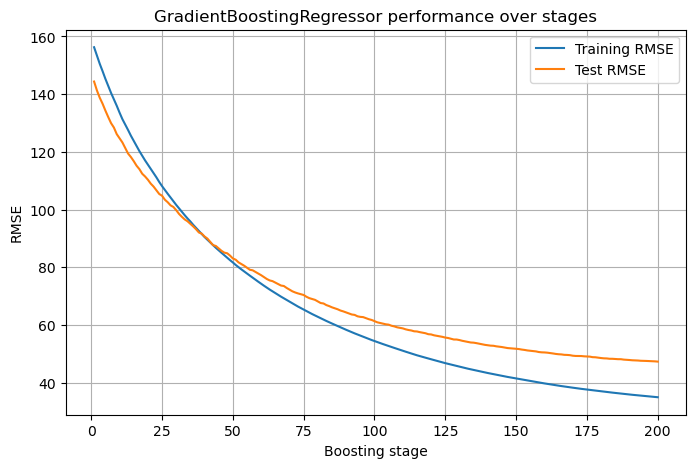

In [24]:
gb_reg.fit(X_train_reg, y_train_reg)

gb_reg_train_rmse = []
gb_reg_test_rmse = []

for y_train_stage, y_test_stage in zip(
    gb_reg.staged_predict(X_train_reg),
    gb_reg.staged_predict(X_test_reg)
):
    gb_reg_train_rmse.append(np.sqrt(mean_squared_error(y_train_reg, y_train_stage)))
    gb_reg_test_rmse.append(np.sqrt(mean_squared_error(y_test_reg, y_test_stage)))

plt.figure(figsize=(8, 5))
plt.plot(range(1, len(gb_reg_train_rmse) + 1), gb_reg_train_rmse, label="Training RMSE")
plt.plot(range(1, len(gb_reg_test_rmse) + 1), gb_reg_test_rmse, label="Test RMSE")
plt.xlabel("Boosting stage")
plt.ylabel("RMSE")
plt.title("GradientBoostingRegressor performance over stages")
plt.legend()
plt.grid(True)
plt.show()

### Interpretation

For regression, lower RMSE is better.

Typical pattern:

- Training RMSE decreases as more stages are added.
- Test RMSE decreases at first.
- If test RMSE later increases, the model may be overfitting.

# Part C: Hyperparameter effects

## 19. Effect of `learning_rate`

The learning rate controls how much each new weak learner contributes.

Small learning rate:

- slower learning,
- often needs more estimators,
- can generalize better.

Large learning rate:

- faster learning,
- can overfit,
- can be unstable.

In [25]:
learning_rates = [0.01, 0.05, 0.1, 0.5, 1.0]
lr_results = []

for lr in learning_rates:
    model = GradientBoostingClassifier(
        n_estimators=150,
        learning_rate=lr,
        max_depth=2,
        random_state=RANDOM_STATE
    )

    model.fit(X_train_clf, y_train_clf)

    lr_results.append({
        "learning_rate": lr,
        "train_accuracy": model.score(X_train_clf, y_train_clf),
        "test_accuracy": model.score(X_test_clf, y_test_clf)
    })

lr_df = pd.DataFrame(lr_results)
lr_df

,learning_rate,train_accuracy,test_accuracy
0,0.01,0.900000,0.883333
1,0.05,0.926190,0.883333
2,0.10,0.971429,0.883333
3,0.50,1.000000,0.872222
4,1.00,1.000000,0.866667


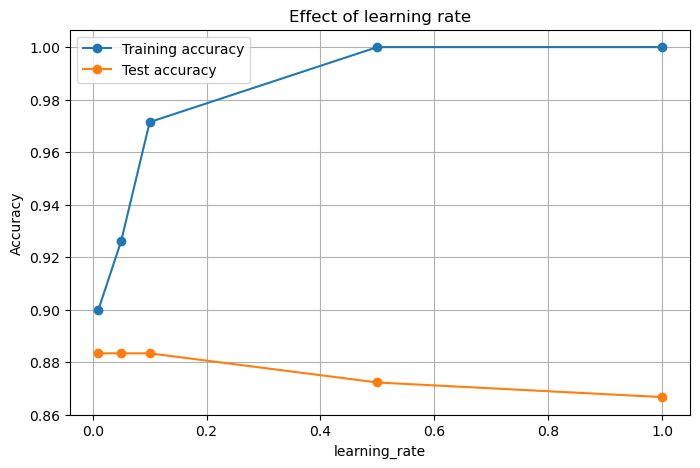

In [26]:
plt.figure(figsize=(8, 5))
plt.plot(lr_df["learning_rate"], lr_df["train_accuracy"], marker="o", label="Training accuracy")
plt.plot(lr_df["learning_rate"], lr_df["test_accuracy"], marker="o", label="Test accuracy")
plt.xlabel("learning_rate")
plt.ylabel("Accuracy")
plt.title("Effect of learning rate")
plt.legend()
plt.grid(True)
plt.show()

## 20. Effect of `n_estimators`

The parameter `n_estimators` controls the number of boosting stages.

More stages can improve performance, but too many stages can overfit.

In [27]:
n_estimators_values = [10, 25, 50, 100, 200, 400]
n_estimators_results = []

for n_estimators in n_estimators_values:
    model = GradientBoostingClassifier(
        n_estimators=n_estimators,
        learning_rate=0.1,
        max_depth=2,
        random_state=RANDOM_STATE
    )

    model.fit(X_train_clf, y_train_clf)

    n_estimators_results.append({
        "n_estimators": n_estimators,
        "train_accuracy": model.score(X_train_clf, y_train_clf),
        "test_accuracy": model.score(X_test_clf, y_test_clf)
    })

n_estimators_df = pd.DataFrame(n_estimators_results)
n_estimators_df

,n_estimators,train_accuracy,test_accuracy
0,10,0.900000,0.883333
1,25,0.904762,0.888889
2,50,0.904762,0.888889
3,100,0.954762,0.888889
4,200,0.978571,0.883333
5,400,1.000000,0.883333


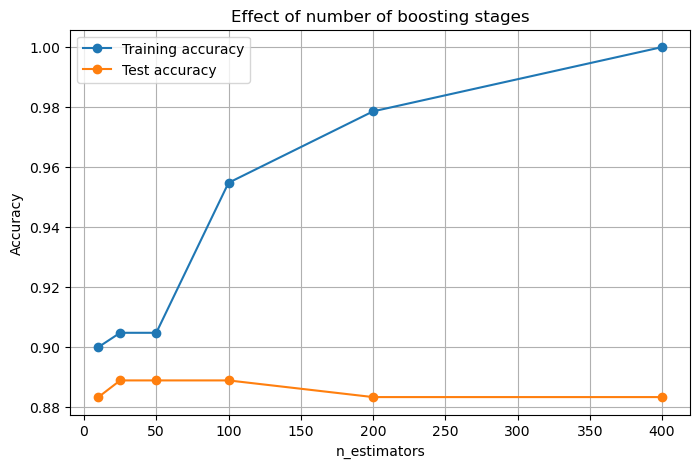

In [28]:
plt.figure(figsize=(8, 5))
plt.plot(n_estimators_df["n_estimators"], n_estimators_df["train_accuracy"], marker="o", label="Training accuracy")
plt.plot(n_estimators_df["n_estimators"], n_estimators_df["test_accuracy"], marker="o", label="Test accuracy")
plt.xlabel("n_estimators")
plt.ylabel("Accuracy")
plt.title("Effect of number of boosting stages")
plt.legend()
plt.grid(True)
plt.show()

## 21. Effect of tree depth

Boosting often works well with shallow trees.

Small depth:

- each tree is weak,
- ensemble learns gradually.

Large depth:

- each tree is more complex,
- can overfit more easily.

In [29]:
depth_values = [1, 2, 3, 5, 8]
depth_results = []

for depth in depth_values:
    model = GradientBoostingClassifier(
        n_estimators=150,
        learning_rate=0.1,
        max_depth=depth,
        random_state=RANDOM_STATE
    )

    model.fit(X_train_clf, y_train_clf)

    depth_results.append({
        "max_depth": depth,
        "train_accuracy": model.score(X_train_clf, y_train_clf),
        "test_accuracy": model.score(X_test_clf, y_test_clf)
    })

depth_df = pd.DataFrame(depth_results)
depth_df

,max_depth,train_accuracy,test_accuracy
0,1,0.911905,0.905556
1,2,0.971429,0.883333
2,3,0.992857,0.883333
3,5,1.000000,0.877778
4,8,1.000000,0.877778


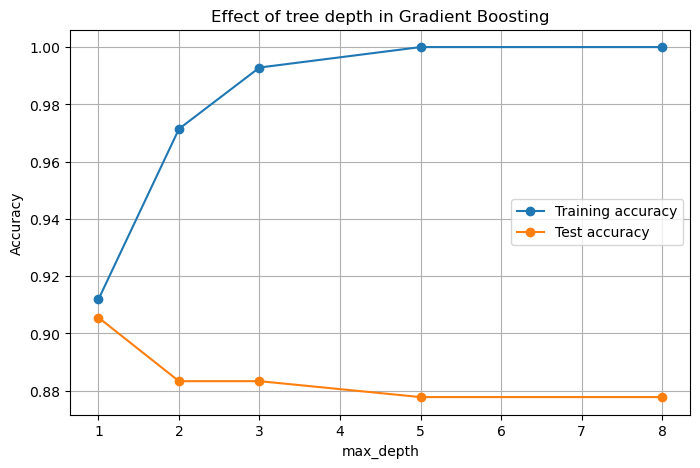

In [30]:
plt.figure(figsize=(8, 5))
plt.plot(depth_df["max_depth"], depth_df["train_accuracy"], marker="o", label="Training accuracy")
plt.plot(depth_df["max_depth"], depth_df["test_accuracy"], marker="o", label="Test accuracy")
plt.xlabel("max_depth")
plt.ylabel("Accuracy")
plt.title("Effect of tree depth in Gradient Boosting")
plt.legend()
plt.grid(True)
plt.show()

# Part D: Hyperparameter tuning with GridSearchCV

## 22. Tune GradientBoostingClassifier

We use a small grid for demonstration.

In practice, large grids can be expensive.

In [31]:
param_grid = {
    "n_estimators": [50, 100, 200],
    "learning_rate": [0.05, 0.1, 0.2],
    "max_depth": [1, 2, 3],
    "subsample": [0.8, 1.0]
}

grid_search = GridSearchCV(
    estimator=GradientBoostingClassifier(random_state=RANDOM_STATE),
    param_grid=param_grid,
    scoring="accuracy",
    cv=5,
    n_jobs=-1
)

grid_search.fit(X_train_clf, y_train_clf)

print("Best parameters:")
print(grid_search.best_params_)
print()
print("Best cross-validation accuracy:", grid_search.best_score_)
print("Final test accuracy:", grid_search.best_estimator_.score(X_test_clf, y_test_clf))

Best parameters:
{'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 200, 'subsample': 0.8}

Best cross-validation accuracy: 0.919047619047619
Final test accuracy: 0.8944444444444445


In [32]:
grid_results = pd.DataFrame(grid_search.cv_results_)
grid_results[[
    "param_n_estimators",
    "param_learning_rate",
    "param_max_depth",
    "param_subsample",
    "mean_test_score",
    "std_test_score",
    "rank_test_score"
]].sort_values("rank_test_score").head(10)

,param_n_estimators,param_learning_rate,param_max_depth,param_subsample,mean_test_score,std_test_score,rank_test_score
16,200,0.05,3,0.8,0.919048,0.013883,1
15,100,0.05,3,1.0,0.914286,0.019048,2
30,50,0.10,3,0.8,0.914286,0.019048,2
32,100,0.10,3,0.8,0.911905,0.022080,4
17,200,0.05,3,1.0,0.909524,0.020757,5
29,200,0.10,2,1.0,0.909524,0.022080,5
10,200,0.05,2,0.8,0.909524,0.022080,5
11,200,0.05,2,1.0,0.909524,0.022080,5
38,100,0.20,1,0.8,0.909524,0.023328,5
45,100,0.20,2,1.0,0.909524,0.026726,5


## 23. Early stopping with HistGradientBoostingClassifier

Histogram Gradient Boosting can use early stopping.

Early stopping means:

> Stop training when validation performance no longer improves.

This can reduce overfitting and save computation.

In [33]:
hist_early = HistGradientBoostingClassifier(
    max_iter=500,
    learning_rate=0.05,
    max_leaf_nodes=15,
    early_stopping=True,
    validation_fraction=0.2,
    n_iter_no_change=10,
    random_state=RANDOM_STATE
)

hist_early.fit(X_train_clf, y_train_clf)

print("Training accuracy:", hist_early.score(X_train_clf, y_train_clf))
print("Test accuracy:", hist_early.score(X_test_clf, y_test_clf))
print("Number of iterations used:", hist_early.n_iter_)

Training accuracy: 0.9404761904761905
Test accuracy: 0.8833333333333333
Number of iterations used: 64


# Part E: Practical guidance

## 24. When should we use boosting?

Boosting is useful when:

1. You have tabular data.
2. Simple models underfit.
3. You want strong predictive performance.
4. You can spend time tuning hyperparameters.
5. You want a strong non-neural baseline.

## When should we be careful?

Boosting can overfit when:

1. `n_estimators` or `max_iter` is too large.
2. `learning_rate` is too high.
3. Trees are too deep.
4. The dataset is very noisy.
5. The validation strategy is weak.

## Practical advice

1. Start with a moderate learning rate, for example `0.05` or `0.1`.
2. Use shallow trees.
3. Tune `n_estimators` and `learning_rate` together.
4. Use cross-validation.
5. Use early stopping where supported.
6. Compare with Random Forest and simpler baselines.

## 25. Mini exercises for students

### Classification exercises

1. Change `noise` in `make_moons` from `0.30` to `0.10` and `0.50`.
2. Compare AdaBoost with decision stumps and AdaBoost with deeper trees.
3. Change `learning_rate` in `AdaBoostClassifier`.
4. Change `max_depth` in `GradientBoostingClassifier`.
5. Use `subsample=0.8` in `GradientBoostingClassifier`.
6. Tune `HistGradientBoostingClassifier`.

### Regression exercises

1. Increase the noise in `make_regression`.
2. Compare `AdaBoostRegressor`, `GradientBoostingRegressor`, and `HistGradientBoostingRegressor`.
3. Change the `loss` function in `GradientBoostingRegressor`.
4. Tune `learning_rate` and `n_estimators`.
5. Visualize train and test RMSE over boosting stages.
6. Compare boosting models with a Random Forest regressor.

### Reflection questions

1. Why does boosting train models sequentially?
2. Why are shallow trees often used in boosting?
3. What is the trade-off between `learning_rate` and `n_estimators`?
4. How can boosting overfit?
5. Why is early stopping useful?

## 26. Summary

In this notebook, we studied boosting methods supported by `scikit-learn`.

### AdaBoost

- Sequentially focuses on difficult examples.
- Supports classification and regression.
- Commonly uses shallow decision trees.

### Gradient Boosting

- Builds an additive model stage by stage.
- Fits new trees to reduce the loss.
- Important parameters include `n_estimators`, `learning_rate`, and `max_depth`.

### Histogram Gradient Boosting

- Faster version of gradient boosting for larger tabular datasets.
- Supports classification and regression.
- Supports early stopping.
- Has native support for missing values.

The key idea of boosting is:

> Each new model should improve the weaknesses of the current ensemble.

## References and further learning

- scikit-learn documentation: `AdaBoostClassifier`
- scikit-learn documentation: `AdaBoostRegressor`
- scikit-learn documentation: `GradientBoostingClassifier`
- scikit-learn documentation: `GradientBoostingRegressor`
- scikit-learn documentation: `HistGradientBoostingClassifier`
- scikit-learn documentation: `HistGradientBoostingRegressor`
- scikit-learn user guide: Ensemble methods